# Assignment 1 



Put this notebook in the same folder as:

- `support.py`
- `dataset_a1.txt`


In [3]:
import random

import time

import numpy as np
import matplotlib.pyplot as plt

from deap import base, creator, tools, algorithms

import support


## GA parameters

These are the initial parameter values for Task 1. 

In [15]:
POPULATION_SIZE = 80
N_GENERATIONS = 45
CROSSOVER_PROBABILITY = 0.8
MUTATION_PROBABILITY = 0.2
TOURNAMENT_SIZE = 3
PER_GENE_MUTATION_PROBABILITY = 0.05

RANDOM_SEED = 42

## Individual representation

A candidate Petri net is represented as a linearized matrix.

There are 12 transitions. Each transition has two numbers: start place and end place. Therefore, one individual has 12 * 2 = 24 integer values. Each integer is a place number from 0 to 8.

In [16]:
INDIVIDUAL_LENGTH = support.NR_TRANSITIONS * 2

LOWER_BOUND = 0
UPPER_BOUND = support.NR_PLACES - 1

print("Individual length:", INDIVIDUAL_LENGTH)
print("Allowed place values:", LOWER_BOUND, "to", UPPER_BOUND)

Individual length: 24
Allowed place values: 0 to 8


## DEAP setup

In [17]:
if "FitnessMax_Task1" not in creator.__dict__:
    creator.create("FitnessMax_Task1", base.Fitness, weights=(1.0,))

if "Individual_Task1" not in creator.__dict__:
    creator.create("Individual_Task1", list, fitness=creator.FitnessMax_Task1)

toolbox = base.Toolbox()

# One gene is one place number from 0 to 8.
toolbox.register("attr_place", random.randint, LOWER_BOUND, UPPER_BOUND)

# One individual is a list of 24 place numbers.
toolbox.register(
    "individual",
    tools.initRepeat,
    creator.Individual_Task1,
    toolbox.attr_place,
    n=INDIVIDUAL_LENGTH,
)

# A population is a list of individuals.
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Fitness function from support.py.
toolbox.register("evaluate", support.fitness)

# Required operators for Task 1.
toolbox.register("mate", tools.cxTwoPoint)

toolbox.register(
    "mutate",
    tools.mutUniformInt,
    low=LOWER_BOUND,
    up=UPPER_BOUND,
    indpb=PER_GENE_MUTATION_PROBABILITY,
)

toolbox.register(
    "select",
    tools.selTournament,
    tournsize=TOURNAMENT_SIZE,
)

## Run the GA

In [18]:
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

population = toolbox.population(n=POPULATION_SIZE)
hall_of_fame = tools.HallOfFame(1)

stats = tools.Statistics(lambda individual: individual.fitness.values[0])
stats.register("avg", np.mean)
stats.register("std", np.std)
stats.register("min", np.min)
stats.register("max", np.max)

start_time = time.time()

population, logbook = algorithms.eaSimple(
    population,
    toolbox,
    cxpb=CROSSOVER_PROBABILITY,
    mutpb=MUTATION_PROBABILITY,
    ngen=N_GENERATIONS,
    stats=stats,
    halloffame=hall_of_fame,
    verbose=True,
)

running_time = time.time() - start_time

gen	nevals	avg     	std    	min	max     
0  	80    	-9.45623	2.85587	-15	-2.73208
1  	67    	-6.8454 	2.3384 	-12	-2.66716
2  	65    	-5.64903	2.09618	-10	-0.75391
3  	73    	-4.16983	1.76436	-9 	0.377802
4  	57    	-3.06259	1.29542	-7 	0.0899158
5  	57    	-2.07254	1.2183 	-5 	0.346757 
6  	67    	-1.33251	0.962146	-4 	0.30509  
7  	66    	-0.77079	0.705668	-3 	0.332844 
8  	63    	-0.151697	0.516257	-1.91008	0.374511 
9  	63    	0.139876 	0.316317	-1      	0.424844 
10 	64    	0.13877  	0.540364	-2.7488 	0.383178 
11 	66    	0.245433 	0.401114	-1.832  	0.424844 
12 	60    	0.300387 	0.292071	-1.58038	0.498903 
13 	65    	0.26053  	0.520587	-3      	0.498903 
14 	69    	0.332974 	0.343467	-1.62549	0.498903 
15 	66    	0.243825 	0.553385	-1.91008	0.498903 
16 	69    	0.429493 	0.225366	-1.50068	0.498903 
17 	71    	0.344253 	0.633172	-4      	0.498903 
18 	69    	0.397074 	0.336387	-1.53026	0.498903 
19 	70    	0.308647 	0.605647	-3.54728	0.498903 
20 	71    	0.289834 	0.555768	-1.6332

## Results

In [19]:
best_individual = hall_of_fame[0]
best_fitness = best_individual.fitness.values[0]

print("Parameter values used:")
print("Population size:", POPULATION_SIZE)
print("Number of generations:", N_GENERATIONS)
print("Crossover probability:", CROSSOVER_PROBABILITY)
print("Mutation probability:", MUTATION_PROBABILITY)
print("Tournament size:", TOURNAMENT_SIZE)
print("Per-gene mutation probability:", PER_GENE_MUTATION_PROBABILITY)
print("Random seed:", RANDOM_SEED)

print("\nRunning time:", round(running_time, 2), "seconds")
print("Best fitness:", best_fitness)

print("\nBest individual:")
print(list(best_individual))

print("\nBest individual as matrix:")
print(support.list_to_array(best_individual))

Parameter values used:
Population size: 80
Number of generations: 45
Crossover probability: 0.8
Mutation probability: 0.2
Tournament size: 3
Per-gene mutation probability: 0.05
Random seed: 42

Running time: 117.58 seconds
Best fitness: 0.4989033189033186

Best individual:
[3, 4, 6, 8, 5, 6, 3, 4, 0, 7, 0, 5, 7, 8, 5, 8, 3, 5, 4, 6, 4, 8, 3, 6]

Best individual as matrix:
[[3 4]
 [6 8]
 [5 6]
 [3 4]
 [0 7]
 [0 5]
 [7 8]
 [5 8]
 [3 5]
 [4 6]
 [4 8]
 [3 6]]


## Plot best fitness at each generation

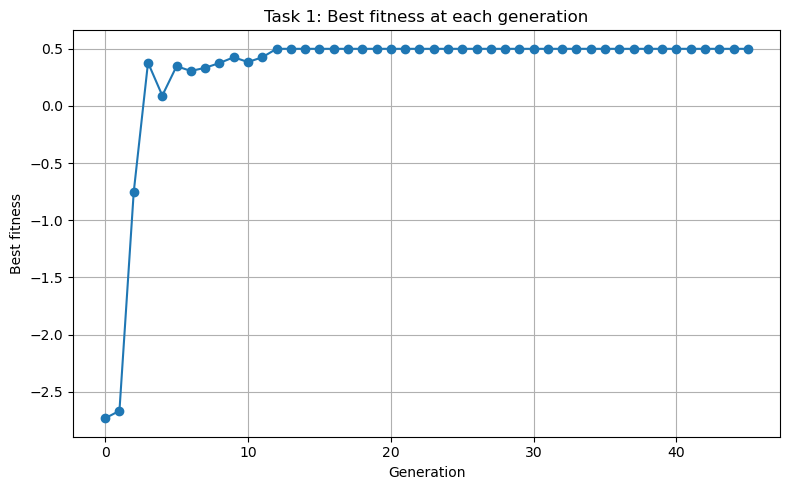

In [20]:
generations = logbook.select("gen")
best_fitness_per_generation = logbook.select("max")

plt.figure(figsize=(8, 5))
plt.plot(generations, best_fitness_per_generation, marker="o")
plt.xlabel("Generation")
plt.ylabel("Best fitness")
plt.title("Task 1: Best fitness at each generation")
plt.grid(True)
plt.tight_layout()
plt.savefig("task1_best_fitness.png", dpi=200)
plt.show()